In [ ]:
import pandas as pd

In [ ]:
csv_es = "es_data.csv"

es_df = pd.read_csv(csv_es)
es_df.head(2)

,id,course_of_study,full_bio,full_image_url,industries,name,organisation,role,school,thumbnail_image_url,wave_id,last_modified_time
0,reclM5g8XAgk138Q1,Mechanical Engineering,"Chinmay Gavankar is Director, Data and Artific...",https://advisorysg-mentorship.s3.ap-southeast-...,['Information and Communications Technology' '...,Chinmay Gavankar,Microsoft Corporation,Director-Data & AI,VJTI University of Mumbai,https://advisorysg-mentorship.s3.ap-southeast-...,2023,2023-07-24T15:01:44.000Z
1,recuMGexISFZy6MkF,"Master of Business Administration, B.Eng in Me...",Denis Koh is the Professional Service Director...,https://advisorysg-mentorship.s3.ap-southeast-...,['Information and Communications Technology' '...,Denis Koh,"Aptos Software Singapore,",Professional Service Director,"University of Technology, Syndey, Nanyang Tech...",https://advisorysg-mentorship.s3.ap-southeast-...,2021-2,2023-04-01T01:25:57.000Z


In [ ]:
# extract only id and name from es_df
es_df = es_df[['id', 'name']]
es_df.head()

,id,name
0,reclM5g8XAgk138Q1,Chinmay Gavankar
1,recuMGexISFZy6MkF,Denis Koh
2,rec7OJSBJ8rCSqJRI,Choon Yin Yee
3,recP44ctWCcSvn1Qr,Derek Chee
4,rec5gZPt1aMIwwmtG,Christian Xia


In [ ]:
csv_file_path = "es_mentor_with_keywords.csv"

df = pd.read_csv(csv_file_path)
df.head(2)

,Unnamed: 0,id,full_bio,industries,organisation,combined_keywords
0,0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...",['Information and Communications Technology' '...,Microsoft Corporation,"['cloud computing services', 'bachelor ’s degr..."
1,1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,['Information and Communications Technology' '...,"Aptos Software Singapore,","['his master of business administration', 'int..."


In [ ]:
df = df[['id', 'full_bio', 'combined_keywords']]
df.head()

,id,full_bio,combined_keywords
0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...","['cloud computing services', 'bachelor ’s degr..."
1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,"['his master of business administration', 'int..."
2,rec7OJSBJ8rCSqJRI,Yee Choon Yin is a Senior Associate within the...,"['associate', 'management', 'choon', 'medium',..."
3,recP44ctWCcSvn1Qr,"In his capacity as a Compliance Testing, Vice ...","['chartered accountant', 'Risk Management Assu..."
4,rec5gZPt1aMIwwmtG,Christian Xia is a consultant at Boston Consul...,"['corporations', 'Hitachi', 'mechanical engine..."


In [ ]:
# join on id
df = pd.merge(df, es_df, on='id', how='left')
df.head()

,id,full_bio,combined_keywords,name
0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...","['cloud computing services', 'bachelor ’s degr...",Chinmay Gavankar
1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,"['his master of business administration', 'int...",Denis Koh
2,rec7OJSBJ8rCSqJRI,Yee Choon Yin is a Senior Associate within the...,"['associate', 'management', 'choon', 'medium',...",Choon Yin Yee
3,recP44ctWCcSvn1Qr,"In his capacity as a Compliance Testing, Vice ...","['chartered accountant', 'Risk Management Assu...",Derek Chee
4,rec5gZPt1aMIwwmtG,Christian Xia is a consultant at Boston Consul...,"['corporations', 'Hitachi', 'mechanical engine...",Christian Xia


In [ ]:
import re

In [ ]:
# Remove duplicate terms based on subset logic
# def remove_common_substrings(terms):
#     """
#     Removes terms from a list if they are found as substrings of other (longer) terms within the list.

#     Args:
#         terms: A list of strings.

#     Returns:
#         A sorted list of unique terms where no term in the list is a substring of another term
#         in the list (case-insensitive comparison). The order of the returned list is based on
#         the alphabetical sorting of the remaining terms.
#     """
#     lowercase_terms = sorted(list(set(term.lower() for term in terms)), key=len, reverse=True)
#     final_terms = set(lowercase_terms)  # Start with all unique lowercase terms

#     for i, longer_term in enumerate(lowercase_terms):
#         for j, shorter_term in enumerate(lowercase_terms):
#             if i != j and shorter_term in final_terms and shorter_term in longer_term:
#                 final_terms.discard(shorter_term)

#     return sorted(list(final_terms))


def process_keywords(row):
    """
    Processes keywords for a given row.  This includes removing square brackets,
    removing keywords that are substrings of the name, and removing duplicate
    keywords where one is a subset of another.

    Args:
        row (pd.Series): A row from the DataFrame containing 'combined_keywords' and 'name' columns.

    Returns:
        list: A list of unique, processed keywords.
    """
    articles = {"a", "an", "the"}

    blacklist_words = {
        "company", "companies", "chips",
        "his", "her", "they", "their", "self", "other",
        "week", "month", "year", "weeks", "months", "years", "today", "time",
        "many", "much",
        "new", "old", "expert", "experts",
        "degree", "lead", "role", "roles", "event", "events",
        "best",
        "cum", "hons",
        "and"
        }

    name_substring = row['name']

    keywords_list = [
          ''.join(re.findall(r'[a-zA-Z0-9\s]+', x.strip().lower()))    # Keep only alphanumeric and whitespace
          .replace('[', '')
          .replace(']', '')
          .replace("'", '')
          .replace('"', '')
          for x in row['combined_keywords'].split(',')
        ]

    # Split the name substring into individual words
    name_parts = name_substring.lower().split()

    updated_keywords = [
        keyword for keyword in keywords_list
        if len(keyword) > 1
          and not any(part in keyword for part in name_parts)    # Check for any name substring in keywords
          and not any(sub_keyword in articles for sub_keyword in keyword.split())
          and not any(len(sub_keyword) == 1 for sub_keyword in keyword.strip().split())
          and not any(char.isdigit() for char in keyword)
          and not any(sub_keyword in blacklist_words for sub_keyword in keyword.strip().split())
    ]

    # updated_keywords = remove_common_substrings(updated_keywords)

    cleaned_updated_keywords = [
        ' '.join(keyword.strip().split())  # Normalize whitespace to single spaces with leading and ending whitespace removed
        for keyword in updated_keywords
        if len(keyword.strip()) > 2  # remove keywords with 2 or fewer characters
    ]

    return list(set(cleaned_updated_keywords))

In [ ]:
# randomly chosen description
RANDOM_IDX = 2738
random_row = df.iloc[RANDOM_IDX]

print(random_row['full_bio'])
print(random_row['combined_keywords'])

# Call the function on the random row
processed_keywords = process_keywords(random_row)
print("\nProcessed Keywords:")
for keyword in processed_keywords:
    print(keyword)
print(f"\nTotal processed keywords: {len(processed_keywords)}")

Joshua Chong is Head of Talent Acquisition at Cialfo, a Singapore-based edtech that streamlines college applications and career guidance processes. Prior to his current appointment, Joshua held roles in similar capacities at Facebook, Zendesk and Grab with experiences ranging from startups to multinational corporations. He graduated from the University of London with a Bachelor's degree in Business Administration and Management, General. 
['corporations', 'capacities', 'talent', 'acquisition', 'singapore - based edtech', 'business administration', 'management', 'degree', 'Cialfo', 'Zendesk', 'Grab', 'the University of London', 'joshua chong', 'general', 'appointment', 'zendesk', 'edtech', 'singapore', 'chong', 'multinational corporations', 'Singapore', 'his current appointment', 'Facebook', 'administration', 'guidance', 'bachelor', 'talent acquisition', 'experiences', 'career', 'applications', "bachelor 's degree", 'business', 'career guidance processes', 'Joshua Chong', 'Joshua', 'pro

In [ ]:
# apply row-wise operation on df
df['processed_keywords'] = df.apply(process_keywords, axis=1)
df

,id,full_bio,combined_keywords,name,processed_keywords
0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...","['cloud computing services', 'bachelor ’s degr...",Chinmay Gavankar,"[microsoft, customer relationship management, ..."
1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,"['his master of business administration', 'int...",Denis Koh,"[federal express, third party logistics servic..."
2,rec7OJSBJ8rCSqJRI,Yee Choon Yin is a Senior Associate within the...,"['associate', 'management', 'choon', 'medium',...",Choon Yin Yee,"[associate, simuniversity of london, enterpris..."
3,recP44ctWCcSvn1Qr,"In his capacity as a Compliance Testing, Vice ...","['chartered accountant', 'Risk Management Assu...",Derek Chee,"[risk management assurance, accountant, manage..."
4,rec5gZPt1aMIwwmtG,Christian Xia is a consultant at Boston Consul...,"['corporations', 'Hitachi', 'mechanical engine...",Christian Xia,"[wide range, manager, urban mobility, boston c..."
...,...,...,...,...,...
4444,recsELlKM2Gsb8ZhH,Zaharan Zohar is a Business Planning Manager a...,"['the University of Wales', 'bachelor ’s degre...",Zaharan Zohar,"[retail banking industries, associate chartere..."
4445,rec2rfU77JqN4RrBG,Xu Zi is Head of Digital Marketing at Samsonit...,"['company', 'Samsonite', 'AKQA', 'associate', ...",Zi Xu,"[associate, political science, social media ef..."
4446,recTpbenCxQEOpDBy,Goh Zong Wei is currently working as a Manager...,"['financial crime investigator', 'certificatio...",Zong Wei Goh,"[investigator, cams, simuniversity of london, ..."
4447,recEExuylDPNkdWeP,Hamid Rahmatullah Bin Abd Razak is a Consultan...,"['translational research', 'public health', 'k...",Hamid Razak,"[wide range, sengkang general hospital campus,..."


In [ ]:
# randomly chosen description
RANDOM_IDX = 367
random_row = df.iloc[RANDOM_IDX]

print('Bio:')
print(random_row['full_bio'])
print('')

print('Keywords:')
print(''.join(random_row['combined_keywords'][1:-1].strip().replace("'",'')))
print('')

print('Processed Keywords:')
print(', '.join(random_row['processed_keywords']))
print('')

Bio:
Fabian Kho is a Manager at ENGIE Impact. Prior to this role, he was the Consultant at Arthur D. Little, an international management consulting firm focused on innovation and strategy. His career interest is in corporate sustainability, especially how businesses can be a force for good. Fabian holds a Bachelor of Business Administration from the National University of Singapore. His pursuit of knowledge on this subject has taken him from a Business degree in NUS to global destinations such as Spain, The Netherlands, Kazakhstan and a working stint in Hong Kong. Fabian has also served as a Management Trainee at Eu Yan Sang International Ltd, where he worked on bridging communication between the MD, EYS Trading and the Senior Management team, and also participated in a restructuring project expanding the Sales office by 50% headcount in 6 months, among other distinctions in the field.

Keywords:
team, Senior Management, fabian kho, sang, eys trading, 6 months, business administration,

In [ ]:
# randomly chosen description
RANDOM_IDX = 483
random_row = df.iloc[RANDOM_IDX]

print('Bio:')
print(random_row['full_bio'])
print('')

print('Keywords:')
print(''.join(random_row['combined_keywords'][1:-1].strip().replace("'",'')))
print('')

print('Processed Keywords:')
print(', '.join(random_row['processed_keywords']))
print('')

Bio:
Wei Lim is a Management Consultant with Kearney, where he has worked across geographies such as the US, Middle East and Southeast Asia, as well as across industries, ranging from digital media and telecommunications to transportation, logistics and consumer goods packaging. Prior to management consulting, Wei Lim had spent 5 years in the media and entertainment industry. Today, he still records and mixes music in his free time, with a passion for microphones and synthesizers. He holds a Diploma in Piano Performance from ABRSM. Wei Lim graduated from the University of Michigan with a Bachelor of Science in Brain Behaviour and Cognitive Science as well as in Sound Engineering. He completed his Master's Degree in Business Administration, Strategy, Economics and Marketing at Carnegie Mellon University.

Keywords:
middle east, cognitive, "his master s degree", management consultant, mellon, brain, years, Southeast Asia, business administration, media entertainment industry, transportat

In [ ]:
import matplotlib.pyplot as plt

count    4449.000000
mean       32.738593
std         4.423434
min         0.000000
25%        30.000000
50%        33.000000
75%        35.000000
max        51.000000
Name: keyword_count, dtype: float64


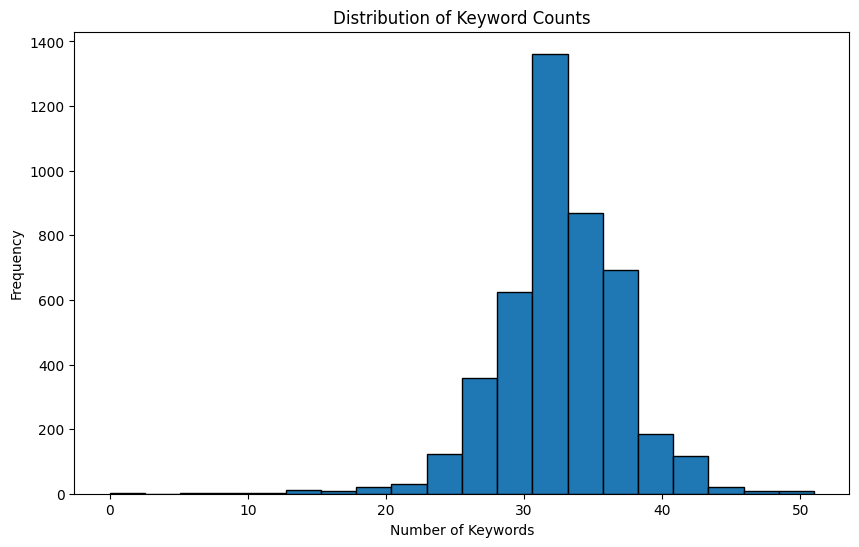

In [ ]:
# Calculate the number of keywords in each row
df['keyword_count'] = df['processed_keywords'].apply(len)

print(df['keyword_count'].describe())

# Create a histogram of the keyword counts
plt.figure(figsize=(10, 6))
plt.hist(df['keyword_count'], bins=20, edgecolor='black')
plt.xlabel('Number of Keywords')
plt.ylabel('Frequency')
plt.title('Distribution of Keyword Counts')
plt.show()

In [ ]:
# Calculate the total sum of keywords
total_keywords = df['keyword_count'].sum()
total_rows = len(df)
mean_keywords = df['keyword_count'].mean()

print(f"Total number of keywords across all rows: {total_keywords}")
print(f"Total number of rows in the DataFrame: {total_rows}")
print(f"Mean keywords per row: {mean_keywords:.2f}")

Total number of keywords across all rows: 145654
Total number of rows in the DataFrame: 4449
Mean keywords per row: 32.74


In [ ]:
# Aggregate all keywords
all_keywords = []
for index, row in df.iterrows():
  if not pd.isna(row['full_bio']):
      keywords = row['processed_keywords']
      all_keywords.extend(keywords)

all_keywords_unique = list(set(all_keywords))

In [ ]:
print(f"Total number of unique keywords: {len(all_keywords_unique)}")
print(f"Total number of keywords in the combined list: {len(all_keywords)}")

Total number of unique keywords: 33750
Total number of keywords in the combined list: 145654


In [ ]:
# randomly sampling for sanity check
all_keywords_unique[:10]

['ogilvys innovation',
 'cybersecurity ecosystem',
 'overarching aim',
 'early fullstack engineer',
 'regulatory regime',
 'associate attorney',
 'agency marketing',
 'strategic advisory',
 'upper management',
 'securities law']

In [ ]:
# Create a DataFrame from the list of unique keywords
df_keywords = pd.DataFrame({'keyword': all_keywords_unique})

# Apply a function to calculate the word count for each keyword
df_keywords['word_count'] = df_keywords['keyword'].apply(lambda phrase: len(str(phrase).split()))
df_keywords

,keyword,word_count
0,ogilvys innovation,2
1,cybersecurity ecosystem,2
2,overarching aim,2
3,early fullstack engineer,3
4,regulatory regime,2
...,...,...
33745,fon,1
33746,how school,2
33747,major projects,2
33748,lenovo pccw solutions limited,4


In [ ]:
df_keywords['word_count'].describe()

,word_count
count,33750.000000
mean,2.376711
std,1.150817
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,17.000000


In [ ]:
import numpy as np

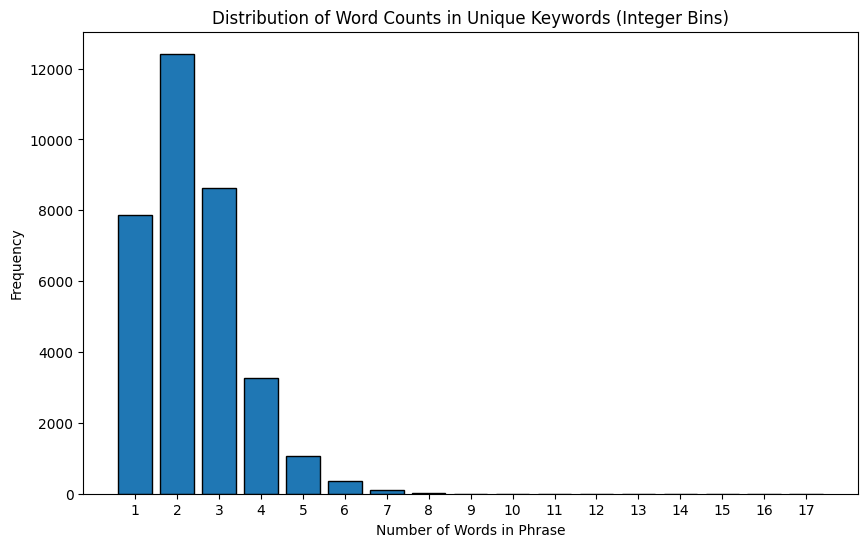


DataFrame showing quantities, percentages, and cumulative percentages per bin:


,word_count,count,percentage,cumulative_percentage
0,1,7873,23.33,23.33
1,2,12420,36.80,60.13
2,3,8620,25.54,85.67
3,4,3270,9.69,95.36
4,5,1065,3.16,98.51
5,6,346,1.03,99.54
6,7,115,0.34,99.88
7,8,29,0.09,99.96
8,9,6,0.02,99.98
9,10,3,0.01,99.99


In [ ]:
# Determine the range of word counts
min_word_count = df_keywords['word_count'].min()
max_word_count = df_keywords['word_count'].max()

# Create integer-based bin edges
bins = np.arange(min_word_count - 0.5, max_word_count + 1.5, 1)

plt.figure(figsize=(10, 6))
plt.hist(df_keywords['word_count'], bins=bins, edgecolor='black', align='mid', rwidth=0.8)
plt.xlabel('Number of Words in Phrase')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts in Unique Keywords (Integer Bins)')
plt.xticks(np.arange(min_word_count, max_word_count + 1, 1))  # Ensure integer ticks on x-axis
plt.show()

# Get histogram data
n, bins_edges = np.histogram(df_keywords['word_count'], bins=bins)

# Create a DataFrame to store the bin quantities and proportions
total_count = n.sum()  # Calculate the total number of data points
bin_counts_df = pd.DataFrame({
    'word_count': np.arange(min_word_count, max_word_count + 1, 1),
    'count': n.astype(int),
    'percentage': (n / total_count) * 100  # Calculate percentage proportion
})

# Calculate the cumulative percentage
bin_counts_df['cumulative_percentage'] = bin_counts_df['percentage'].cumsum().map('{:.2f}'.format)

# Format the percentage column to two decimal places
bin_counts_df['percentage'] = bin_counts_df['percentage'].map('{:.2f}'.format)

print("\nDataFrame showing quantities, percentages, and cumulative percentages per bin:")
bin_counts_df

In [ ]:
# abt 95% of population captured with 4 words or less
WORD_LIMIT = 4

filtered_keywords_df = df_keywords[df_keywords['word_count'] <= WORD_LIMIT]
filtered_keywords_df.sample(n=10, random_state=42)

,keyword,word_count
29005,mid senior level bankers,4
12895,emergency medicine,2
5047,internal audit professionals,3
26917,national sales manager,3
33749,product owner solutions architect,4
23846,united nations high commissioner,4
21629,volvo,1
16426,infrastructure,1
19813,home loan,2
31334,youtube fanfest,2


In [ ]:
# Filter the DataFrame for keywords with 4 or more words
long_keywords_df = df_keywords[df_keywords['word_count'] > WORD_LIMIT]
long_keywords_df.sample(n=10, random_state=42)

,keyword,word_count
11473,technical account management project delivery,5
14087,its investment decision making process,5
15454,mis asias it excellence awards,5
8782,harvard th chan school of public health,7
3852,high value practical finance solutions,5
27276,sub saharan africa middle east markets,6
3613,various international local law firms,5
17230,full value procurement enterprise asset manage...,7
13752,coronary artery bypass grafting surgery,5
9499,nyu stern school of business,5


In [ ]:
!pip install wordcloud matplotlib

In [ ]:
from wordcloud import WordCloud

In [ ]:
filtered_keywords = filtered_keywords_df['keyword']

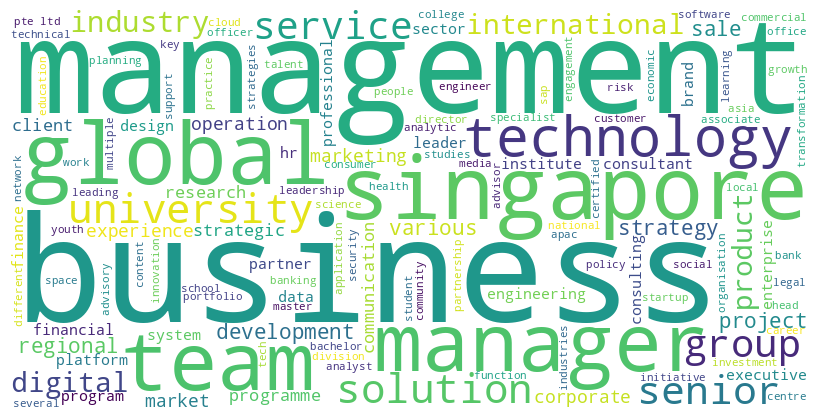

In [ ]:
# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    min_font_size=10
).generate(' '.join(filtered_keywords))

# Display the generated image
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [ ]:
# random filtering for sanity check
START = 115
END = 130

filtered_keywords_df[START:END]

,keyword,word_count
118,commercial special projects,3
119,majoring,1
120,forefront,1
121,foreign law enforcement counterparts,4
122,solution strategist,2
123,procter gamble,2
124,manufacturing industries,2
125,weber shandwick,2
126,government bodies,2
127,various banking businesses,3


In [ ]:
import csv

In [ ]:
csv_file_path = 'unique_mentor_keywords_with_substrings_v2.csv'

try:
    with open(csv_file_path, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        # Write a header row (optional)
        writer.writerow(['keyword'])
        # Write each keyword as a new row
        for keyword in filtered_keywords:
            writer.writerow([keyword])
    print(f"Successfully stored unique keywords in '{csv_file_path}'")
except Exception as e:
    print(f"An error occurred while writing to CSV: {e}")

Successfully stored unique keywords in 'unique_mentor_keywords_with_substrings_v2.csv'


In [ ]:
# Finding elements where bio is NaN

# Sort the DataFrame by keyword count in ascending order
df_sorted = df.sort_values(by='keyword_count')

result_df = df_sorted[(df_sorted['full_bio'].isna()) | (df_sorted['combined_keywords'] == 1)]
result_df

,id,full_bio,combined_keywords,name,processed_keywords,keyword_count
1796,rec0aAmejuxjcS0Cc,NaN,[],Sanjay Chaudhari,[],0
2044,recRin4Y1qag1tRGF,NaN,[],Loveet Kumar,[],0
630,recQOmQp80Tme96Xm,NaN,[],Krishna Anand,[],0
